# 02 Retrieval Benchmark

Simple notebook-only benchmark. It uses the frozen RAGAS-generated testset, compares retrieval methods, writes reports, and selects the method by a fixed score. There is no separate handcrafted testset.

In [1]:

from pathlib import Path
import json
import math
import os
import sys
from collections import defaultdict

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib-cache"))

import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import Dataset
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display
from rank_bm25 import BM25Okapi
from ragas import evaluate
from sklearn.feature_extraction.text import TfidfVectorizer

from src.data.chunking import chunk_documents
from src.data.clean_text import normalize_for_match, tokenize_vi
from src.data.load_dataset import load_documents_from_jsonl
from src.data.schema import SearchResult

CORPUS_PATH = PROJECT_ROOT / "data/processed/labor_corpus.jsonl"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
RAGAS_TESTSET_JSON = REPORTS_DIR / "ragas_testset.json"
RAGAS_TESTSET_MD = REPORTS_DIR / "ragas_testset.md"
RETRIEVAL_JSON = REPORTS_DIR / "retrieval_evaluation.json"
RETRIEVAL_MD = REPORTS_DIR / "retrieval_evaluation.md"
RAG_ANSWERS_JSON = REPORTS_DIR / "rag_answers.json"
RAGAS_EVAL_JSON = REPORTS_DIR / "ragas_evaluation.json"
RAGAS_EVAL_MD = REPORTS_DIR / "ragas_evaluation.md"

DEFAULT_MODEL = "gemini-3.1-flash-lite"
DEFAULT_EMBEDDING_MODEL = "models/gemini-embedding-001"
TOP_K = 5
BENCHMARK_MAX_CHUNKS = 3500
METHODS = ["bm25", "vector", "hybrid", "hybrid_rrf", "hybrid_rrf_mmr"]

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def gemini_keys():
    load_dotenv(PROJECT_ROOT / ".env")
    raw_values = [
        os.getenv("GOOGLE_API_KEY") or "",
        os.getenv("GEMINI_API_KEY") or "",
        os.getenv("GEMINI_API_KEYS") or "",
    ]
    keys, seen = [], set()
    for raw_value in raw_values:
        for key in raw_value.split(","):
            key = key.strip()
            if key and key not in seen:
                keys.append(key)
                seen.add(key)
    return keys


def load_ragas_testset():
    if not RAGAS_TESTSET_JSON.exists():
        raise FileNotFoundError("Missing reports/ragas_testset.json. Run the RAGAS TestsetGenerator cell first.")
    payload = json.loads(RAGAS_TESTSET_JSON.read_text(encoding="utf-8"))
    if not payload.get("generated_with_ragas"):
        raise ValueError("reports/ragas_testset.json must come from RAGAS TestsetGenerator.")
    items = payload.get("items") or []
    if len(items) < 30:
        raise ValueError("RAGAS testset must contain at least 30 accepted questions.")
    return payload, items


def save_ragas_testset(items):
    payload = {
        "generated_with_ragas": True,
        "candidate_target": 40,
        "accepted_count": len(items),
        "items": items,
    }
    RAGAS_TESTSET_JSON.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
    lines = [
        "# RAGAS Testset",
        "",
        "- Generated with RAGAS TestsetGenerator: `True`",
        f"- Accepted questions: `{len(items)}`",
        "",
        "| ID | Topic | Source | Question |",
        "|---|---|---|---|",
    ]
    for item in items:
        lines.append(f"| {item['id']} | {item['topic']} | {item['source']} | {item['question']} |")
    RAGAS_TESTSET_MD.write_text("\n".join(lines) + "\n", encoding="utf-8")
    return payload


def sanitize(value):
    if isinstance(value, dict):
        return {key: sanitize(item) for key, item in value.items()}
    if isinstance(value, list):
        return [sanitize(item) for item in value]
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value


C:\Users\Acer Nitro\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. RAGAS Testset

Load the frozen RAGAS testset. If it is missing, generate it with RAGAS TestsetGenerator.

In [2]:

def generate_ragas_testset():
    keys = gemini_keys()
    if not keys:
        raise RuntimeError("Gemini key is required to generate a RAGAS testset.")
    os.environ.setdefault("GOOGLE_API_KEY", keys[0])

    from langchain_core.documents import Document
    from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
    from ragas.embeddings.base import LangchainEmbeddingsWrapper
    from ragas.llms.base import LangchainLLMWrapper
    from ragas.testset import TestsetGenerator
    from ragas.testset.persona import Persona
    from ragas.testset.synthesizers.single_hop.specific import SingleHopSpecificQuerySynthesizer

    chunks = [chunk for chunk in chunk_documents(load_documents_from_jsonl(str(CORPUS_PATH))) if len(chunk.text) >= 400]
    stride = max(1, len(chunks) // 12)
    source_docs = [
        Document(page_content=chunk.text[:600], metadata={"doc_id": chunk.doc_id, "title": chunk.title, "chunk_id": chunk.chunk_id})
        for chunk in chunks[::stride][:12]
    ]
    llm_context = "Generate Vietnamese labor-law benchmark questions and reference answers from the provided legal context."
    llm = LangchainLLMWrapper(ChatGoogleGenerativeAI(model=DEFAULT_MODEL, google_api_key=keys[0], temperature=0))
    embeddings = LangchainEmbeddingsWrapper(GoogleGenerativeAIEmbeddings(model=DEFAULT_EMBEDDING_MODEL, google_api_key=keys[0]))
    personas = [
        Persona(name="Worker", role_description="An employee asking about labor-law rights."),
        Persona(name="Employer", role_description="An HR manager checking labor-law compliance."),
        Persona(name="LegalAdvisor", role_description="A legal advisor reviewing labor-law questions."),
    ]
    generator = TestsetGenerator(llm=llm, embedding_model=embeddings, persona_list=personas, llm_context=llm_context)
    testset = generator.generate_with_langchain_docs(
        source_docs,
        testset_size=40,
        query_distribution=[(SingleHopSpecificQuerySynthesizer(llm=llm, llm_context=llm_context), 1.0)],
        raise_exceptions=False,
    )
    rows = []
    for idx, row in testset.to_pandas().iterrows():
        question = str(row.get("user_input") or row.get("question") or "").strip()
        reference = str(row.get("reference") or row.get("reference_contexts") or "").strip()
        if question and len(question.split()) >= 5:
            rows.append({
                "id": f"ragas_{idx + 1:03d}",
                "question": question,
                "reference": reference or question,
                "topic": str(row.get("synthesizer_name") or "ragas_generated"),
                "source": "ragas_testset_generator",
            })
    if len(rows) < 30:
        raise RuntimeError(f"RAGAS generated only {len(rows)} valid questions.")
    return save_ragas_testset(rows[:30]), rows[:30]


try:
    testset_meta, testset = load_ragas_testset()
except FileNotFoundError:
    testset_meta, testset = generate_ragas_testset()

pd.DataFrame([{k: testset_meta.get(k) for k in ["generated_with_ragas", "candidate_target", "accepted_count"]}])


,generated_with_ragas,candidate_target,accepted_count
0,True,40,30


In [3]:
pd.DataFrame(testset)[["id", "topic", "source", "question"]].head(12)

,id,topic,source,question
0,ragas_001,single_hop_specific_query_synthesizer,ragas_testset_generator,Theo quy định tại CHƯƠNG VI thì khi xí nghiệp ...
1,ragas_002,single_hop_specific_query_synthesizer,ragas_testset_generator,Quy trình giải thể Xí nghiệp liên doanh được q...
2,ragas_003,single_hop_specific_query_synthesizer,ragas_testset_generator,Khi nào thì hội đồng quản trị của xí nghiệp li...
3,ragas_004,single_hop_specific_query_synthesizer,ragas_testset_generator,CHƯƠNG VI nói về cái gì vậy ạ?
4,ragas_005,single_hop_specific_query_synthesizer,ragas_testset_generator,anh oi cho hoi cai Nghị định số 103/1999/NĐ-CP...
5,ragas_006,single_hop_specific_query_synthesizer,ragas_testset_generator,Theo Nghị định số 103/1999/NĐ-CP của Chính phủ...
6,ragas_007,single_hop_specific_query_synthesizer,ragas_testset_generator,Nghị định số 103/1999/NĐ-CP quy định gì về việ...
7,ragas_008,single_hop_specific_query_synthesizer,ragas_testset_generator,Khi các bên lập phương án dựa trên hướng phát ...
8,ragas_009,single_hop_specific_query_synthesizer,ragas_testset_generator,UBND TỈNH LÂM ĐỒNG đã đánh giá như thế nào về ...
9,ragas_010,single_hop_specific_query_synthesizer,ragas_testset_generator,"Theo chỉ thị của UBND tỉnh Lâm Đồng, tình hình..."


## 2. Retrieval Benchmark

In [4]:

def chunk_text(chunk):
    return f"{chunk.title} {chunk.text}"


def normalize_rows(matrix):
    norms = np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-12
    return np.asarray(matrix / norms, dtype="float32")


class NotebookRetriever:
    def __init__(self, chunks):
        self.chunks = chunks
        self.bm25 = BM25Okapi([tokenize_vi(chunk_text(chunk)) for chunk in chunks])
        self.vectorizer = TfidfVectorizer(max_features=384, ngram_range=(1, 2))
        self.embeddings = normalize_rows(self.vectorizer.fit_transform([chunk_text(chunk) for chunk in chunks]).toarray())
        self.index = faiss.IndexFlatIP(self.embeddings.shape[1])
        self.index.add(self.embeddings)

    def retrieve(self, query, method, top_k=TOP_K):
        sparse = self.retrieve_bm25(query, max(30, top_k * 5))
        vector = self.retrieve_vector(query, max(30, top_k * 5))
        if method == "bm25":
            return sparse[:top_k]
        if method == "vector":
            return vector[:top_k]
        if method == "hybrid":
            return self.weighted_hybrid(sparse, vector, top_k)
        if method == "hybrid_rrf":
            return self.rrf([sparse, vector], top_k)
        if method == "hybrid_rrf_mmr":
            return self.mmr(self.rrf([sparse, vector], max(20, top_k * 4)), top_k)
        raise ValueError(method)

    def retrieve_bm25(self, query, top_k):
        scores = self.bm25.get_scores(tokenize_vi(query))
        indices = sorted(range(len(scores)), key=lambda idx: scores[idx], reverse=True)[:top_k]
        return [SearchResult(self.chunks[idx], float(scores[idx]), "bm25", rank) for rank, idx in enumerate(indices, start=1)]

    def retrieve_vector(self, query, top_k):
        query_vector = normalize_rows(self.vectorizer.transform([query]).toarray())
        scores, indices = self.index.search(query_vector, top_k)
        return [
            SearchResult(self.chunks[int(idx)], float(score), "vector", rank)
            for rank, (idx, score) in enumerate(zip(indices[0], scores[0]), start=1)
            if idx >= 0
        ]

    @staticmethod
    def minmax(results):
        if not results:
            return {}
        scores = [result.score for result in results]
        low, high = min(scores), max(scores)
        if high == low:
            return {result.chunk.chunk_id: 1.0 for result in results}
        return {result.chunk.chunk_id: (result.score - low) / (high - low) for result in results}

    def weighted_hybrid(self, sparse, vector, top_k):
        sparse_scores = self.minmax(sparse)
        vector_scores = self.minmax(vector)
        chunks = {result.chunk.chunk_id: result.chunk for result in sparse + vector}
        scores = defaultdict(float)
        for chunk_id, score in sparse_scores.items():
            scores[chunk_id] += 0.55 * score
        for chunk_id, score in vector_scores.items():
            scores[chunk_id] += 0.45 * score
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(chunks[chunk_id], float(score), "hybrid", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    @staticmethod
    def rrf(result_lists, top_k):
        scores, chunks = defaultdict(float), {}
        for results in result_lists:
            for rank, result in enumerate(results, start=1):
                chunks[result.chunk.chunk_id] = result.chunk
                scores[result.chunk.chunk_id] += 1.0 / (60 + rank)
        ordered = sorted(scores.items(), key=lambda item: item[1], reverse=True)[:top_k]
        return [SearchResult(chunks[chunk_id], float(score), "hybrid_rrf", rank) for rank, (chunk_id, score) in enumerate(ordered, start=1)]

    @staticmethod
    def mmr(results, top_k):
        selected, seen_docs = [], set()
        for result in results:
            if result.chunk.doc_id in seen_docs and len(selected) < max(1, top_k - 1):
                continue
            selected.append(result)
            seen_docs.add(result.chunk.doc_id)
            if len(selected) == top_k:
                break
        if len(selected) < top_k:
            selected.extend(result for result in results if result not in selected)
        return [SearchResult(result.chunk, result.score, "hybrid_rrf_mmr", rank) for rank, result in enumerate(selected[:top_k], start=1)]


In [5]:

STOPWORDS = {"cua", "cho", "cac", "mot", "nhung", "theo", "quy", "dinh", "duoc", "khong", "trong", "voi", "khi", "thi", "la", "ve", "va"}


def content_tokens(text):
    return {token for token in tokenize_vi(normalize_for_match(text)) if len(token) > 2 and token not in STOPWORDS}


def overlap_score(result, item):
    expected = content_tokens(f"{item.get('reference', '')} {item.get('question', '')}")
    observed = content_tokens(chunk_text(result.chunk))
    return len(expected & observed) / max(len(expected), 1)


def local_metrics(results, item):
    gains = [overlap_score(result, item) for result in results[:TOP_K]]
    dcg = sum(gain / math.log2(idx + 2) for idx, gain in enumerate(gains))
    ideal = sum(gain / math.log2(idx + 2) for idx, gain in enumerate(sorted(gains, reverse=True)))
    first = next((idx for idx, gain in enumerate(gains, start=1) if gain >= 0.12), None)
    combined = " ".join(chunk_text(result.chunk) for result in results[:TOP_K])
    recall = len(content_tokens(combined) & content_tokens(f"{item.get('reference', '')} {item.get('question', '')}")) / max(len(content_tokens(f"{item.get('reference', '')} {item.get('question', '')}")), 1)
    return {
        "recall@5": 1.0 if first else 0.0,
        "mrr": 1.0 / first if first else 0.0,
        "ndcg@5": dcg / ideal if ideal else 0.0,
        "lexical_context_precision": sum(gains) / max(len(gains), 1),
        "lexical_context_recall": recall,
        "citation_coverage": sum(bool(result.chunk.title and result.chunk.doc_id) for result in results) / max(len(results), 1),
    }


def ragas_context_scores(rows):
    from ragas.metrics._context_precision import NonLLMContextPrecisionWithReference
    from ragas.metrics._context_recall import NonLLMContextRecall

    output = {}
    for method in METHODS:
        dataset = Dataset.from_list([
            {
                "user_input": row["question"],
                "retrieved_contexts": row["contexts"],
                "reference_contexts": [row["reference"]],
                "reference": row["reference"],
            }
            for row in rows if row["method"] == method
        ])
        frame = evaluate(dataset=dataset, metrics=[NonLLMContextPrecisionWithReference(), NonLLMContextRecall()], show_progress=False).to_pandas()
        output[method] = {
            "ragas_context_precision": float(frame["non_llm_context_precision_with_reference"].mean()),
            "ragas_context_recall": float(frame["non_llm_context_recall"].mean()),
        }
    return output


def selection_score(row):
    cp = row.get("ragas_context_precision")
    cr = row.get("ragas_context_recall")
    if cp is None or not math.isfinite(cp):
        cp = row["lexical_context_precision"]
    if cr is None or not math.isfinite(cr):
        cr = row["lexical_context_recall"]
    return 0.30 * row["mrr"] + 0.25 * row["ndcg@5"] + 0.25 * cp + 0.20 * cr


In [6]:

chunks = chunk_documents(load_documents_from_jsonl(str(CORPUS_PATH)))[:BENCHMARK_MAX_CHUNKS]
retriever = NotebookRetriever(chunks)
details, ragas_rows = [], []

for method in METHODS:
    for item in testset:
        results = retriever.retrieve(item["question"], method, TOP_K)
        row = {
            "question_id": item["id"],
            "question": item["question"],
            "reference": item["reference"],
            "method": method,
            "top_title": results[0].chunk.title if results else None,
            "contexts": [result.chunk.text for result in results],
            **local_metrics(results, item),
        }
        details.append({key: value for key, value in row.items() if key != "contexts"})
        ragas_rows.append(row)

ragas_scores = ragas_context_scores(ragas_rows)
summary = []
for method in METHODS:
    rows = [row for row in details if row["method"] == method]
    aggregate = {
        "method": method,
        **{metric: sum(row[metric] for row in rows) / len(rows) for metric in ["recall@5", "mrr", "ndcg@5", "lexical_context_precision", "lexical_context_recall", "citation_coverage"]},
        "ragas_context_precision": ragas_scores.get(method, {}).get("ragas_context_precision"),
        "ragas_context_recall": ragas_scores.get(method, {}).get("ragas_context_recall"),
    }
    aggregate["selection_score"] = selection_score(aggregate)
    summary.append(aggregate)

selected_method = sorted(summary, key=lambda row: (row["selection_score"], row["mrr"], row["ndcg@5"]), reverse=True)[0]["method"]
retrieval_report = {
    "testset_size": len(testset),
    "num_chunks": len(chunks),
    "methods": METHODS,
    "ragas_backend": "ragas_evaluate_non_llm",
    "selected_method": selected_method,
    "summary": summary,
    "details": details,
}
RETRIEVAL_JSON.write_text(json.dumps(sanitize(retrieval_report), ensure_ascii=False, indent=2), encoding="utf-8")
retrieval_df = pd.DataFrame(summary).sort_values("selection_score", ascending=False)
print("selected:", selected_method)
retrieval_df


selected: hybrid


,method,recall@5,mrr,ndcg@5,lexical_context_precision,lexical_context_recall,citation_coverage,ragas_context_precision,ragas_context_recall,selection_score
2,hybrid,1.0,1.0,0.958729,0.569532,0.887560,1.0,0.030556,0.100000,0.567321
3,hybrid_rrf,1.0,1.0,0.940614,0.552570,0.873842,1.0,0.033333,0.100000,0.563487
1,vector,1.0,1.0,0.931520,0.473102,0.787708,1.0,0.050000,0.066667,0.558713
4,hybrid_rrf_mmr,1.0,1.0,0.946812,0.514502,0.860973,1.0,0.027778,0.066667,0.556981
0,bm25,1.0,1.0,0.976453,0.588803,0.884928,1.0,0.008333,0.033333,0.552863


## 3. Figures and Report

### retrieval_selection_score.png

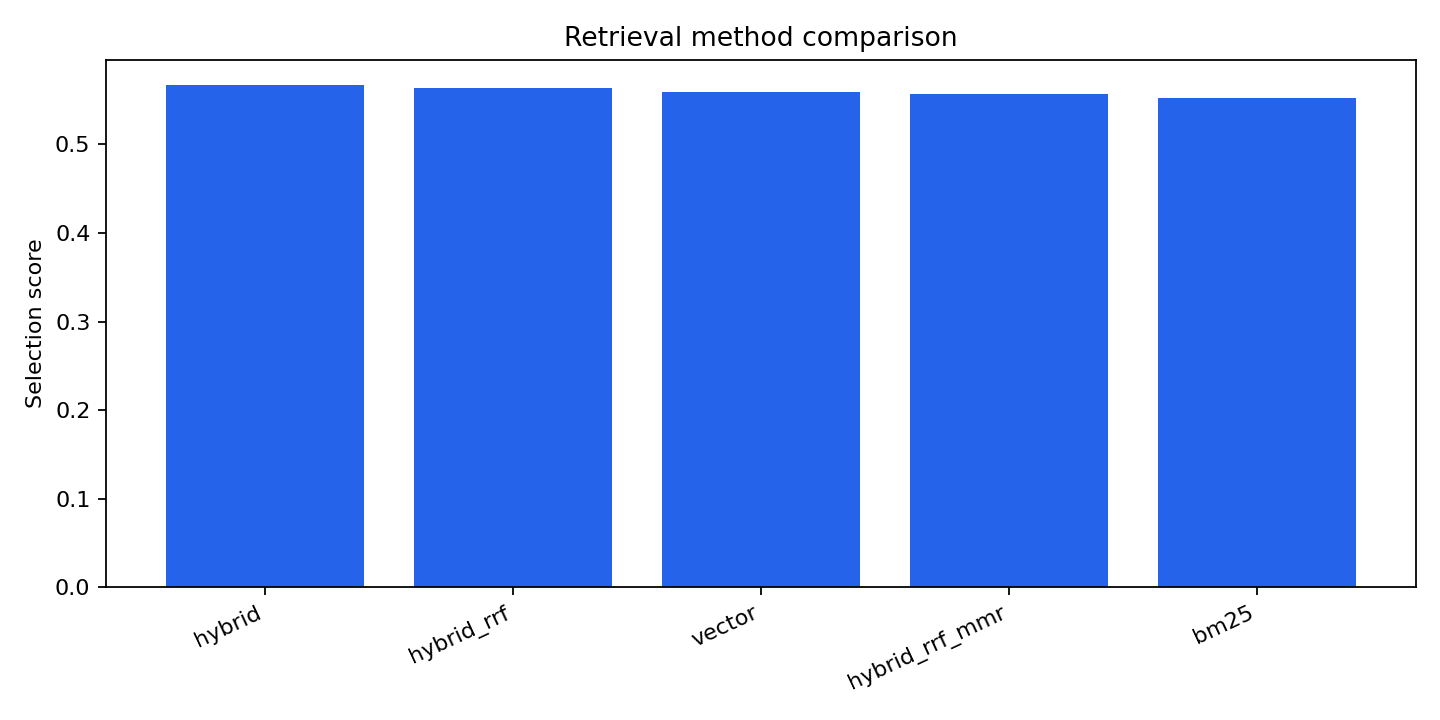

### retrieval_metric_comparison.png

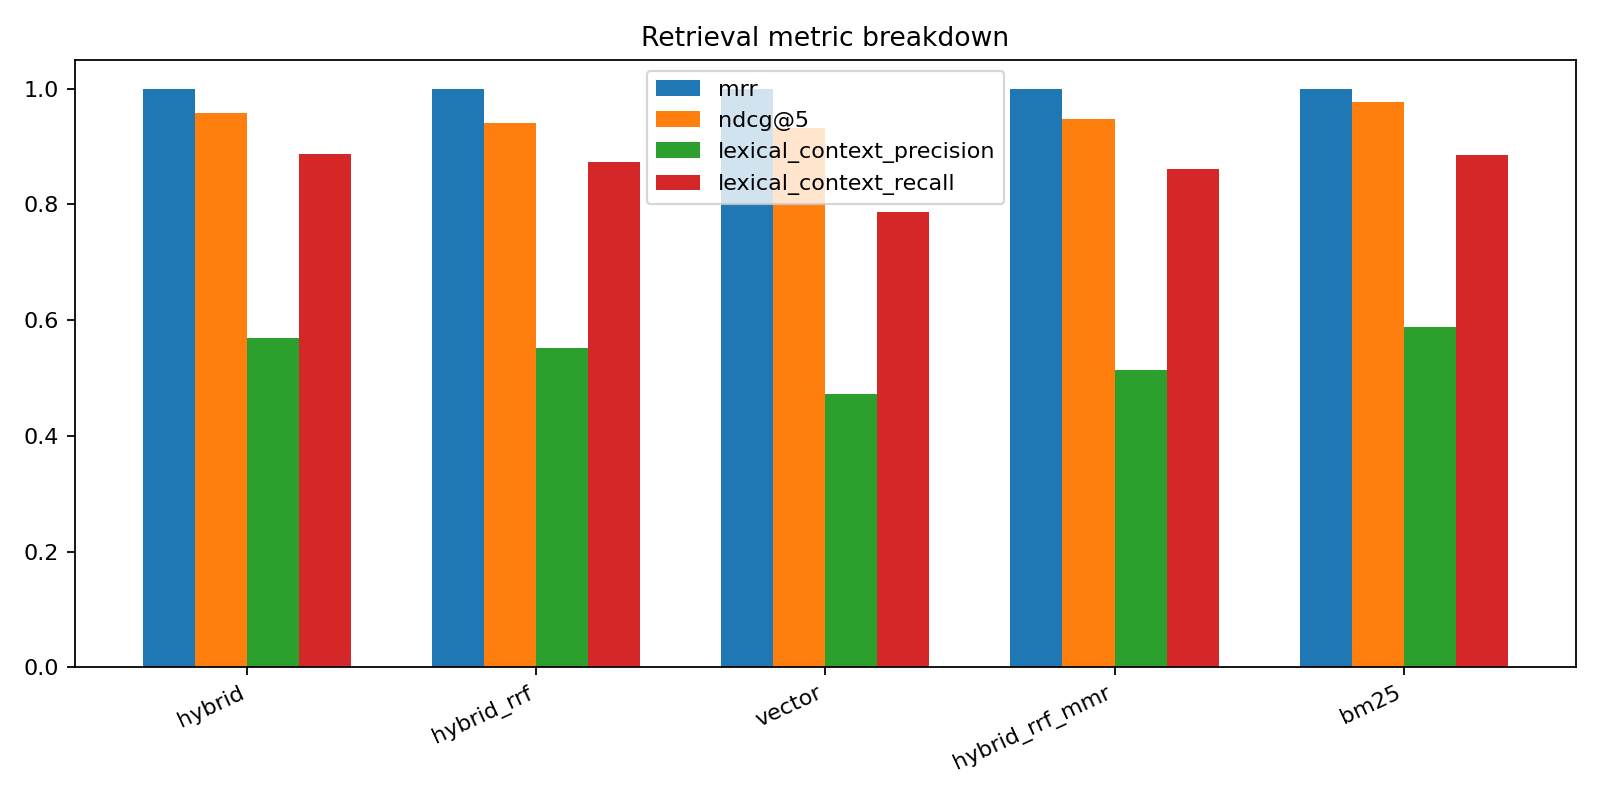

### retrieval_query_heatmap.png

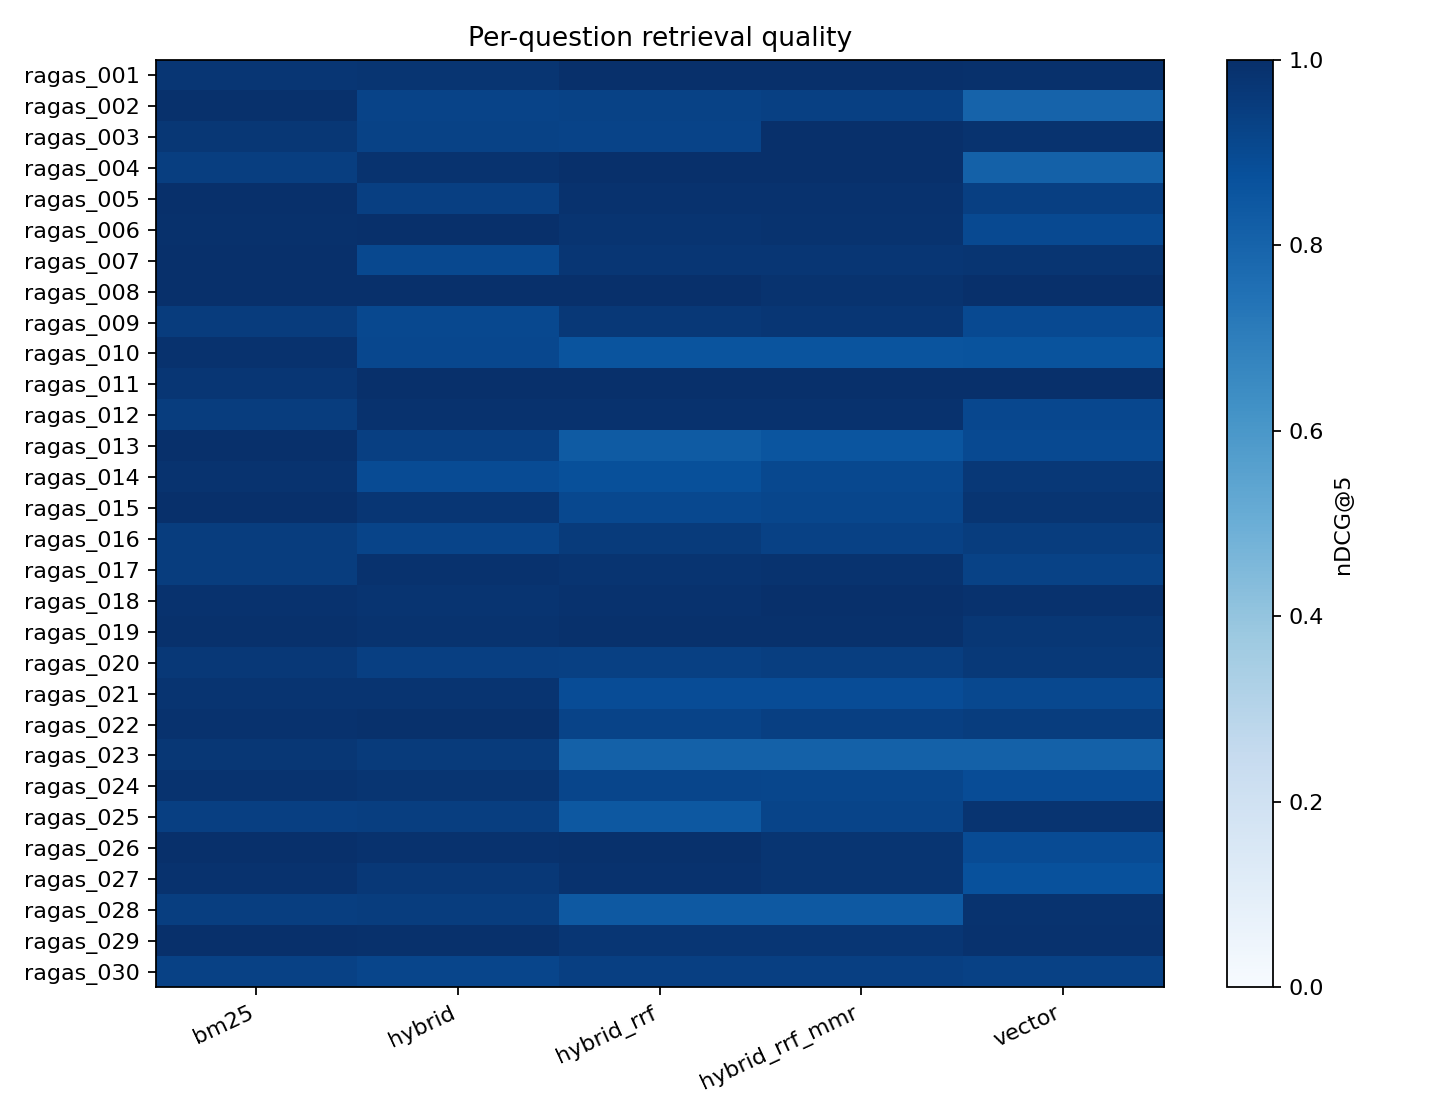

In [7]:

ordered = retrieval_df.sort_values("selection_score", ascending=False)
plt.figure(figsize=(9, 4.5))
plt.bar(ordered["method"], ordered["selection_score"], color="#2563eb")
plt.ylabel("Selection score")
plt.title("Retrieval method comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_selection_score.png", dpi=160)
plt.close()

metric_cols = ["mrr", "ndcg@5", "lexical_context_precision", "lexical_context_recall"]
x = np.arange(len(retrieval_df["method"]))
width = 0.18
plt.figure(figsize=(10, 5))
for idx, metric in enumerate(metric_cols):
    plt.bar(x + (idx - 1.5) * width, retrieval_df[metric], width=width, label=metric)
plt.xticks(x, retrieval_df["method"], rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.title("Retrieval metric breakdown")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_metric_comparison.png", dpi=160)
plt.close()

details_df = pd.DataFrame(details)
pivot = details_df.pivot_table(index="question_id", columns="method", values="ndcg@5", aggfunc="mean")
plt.figure(figsize=(9, 7))
plt.imshow(pivot.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="nDCG@5")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=25, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Per-question retrieval quality")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "retrieval_query_heatmap.png", dpi=160)
plt.close()

for name in ["retrieval_selection_score.png", "retrieval_metric_comparison.png", "retrieval_query_heatmap.png"]:
    display(Markdown(f"### {name}"))
    display(Image(filename=str(FIGURES_DIR / name)))


In [8]:

lines = [
    "# Retrieval Evaluation",
    "",
    f"- Testset size: `{retrieval_report['testset_size']}`",
    f"- Benchmark chunks: `{retrieval_report['num_chunks']}`",
    f"- RAGAS retrieval metrics backend: `{retrieval_report['ragas_backend']}`",
    f"- Selected method: `{selected_method}`",
    "",
    "| Method | MRR | nDCG@5 | Lexical CP | Lexical CR | RAGAS CP | RAGAS CR | Selection score |",
    "|---|---:|---:|---:|---:|---:|---:|---:|",
]
for row in retrieval_df.to_dict("records"):
    lines.append(
        f"| {row['method']} | {row['mrr']:.3f} | {row['ndcg@5']:.3f} | "
        f"{row['lexical_context_precision']:.3f} | {row['lexical_context_recall']:.3f} | "
        f"{row['ragas_context_precision']:.3f} | {row['ragas_context_recall']:.3f} | {row['selection_score']:.3f} |"
    )
lines.extend(["", "## Figures", "", "- `reports/figures/retrieval_selection_score.png`", "- `reports/figures/retrieval_metric_comparison.png`", "- `reports/figures/retrieval_query_heatmap.png`", ""])
RETRIEVAL_MD.write_text("\n".join(lines), encoding="utf-8")
Markdown(f"**Selected retrieval method:** `{selected_method}` with score `{retrieval_df.iloc[0]['selection_score']:.3f}`.")


**Selected retrieval method:** `hybrid` with score `0.567`.

In [9]:
details_df[["question_id", "method", "mrr", "ndcg@5", "lexical_context_precision", "lexical_context_recall", "top_title"]].head(30)

,question_id,method,mrr,ndcg@5,lexical_context_precision,lexical_context_recall,top_title
0,ragas_001,bm25,1.0,0.973054,0.692593,1.000000,Hướng dẫn thi hành Quy chế lao động đối với cá...
1,ragas_002,bm25,1.0,0.992881,0.560656,0.885246,Về việc chấn chỉnh và tổ chức lại sản xuất và ...
2,ragas_003,bm25,1.0,0.972628,0.640000,0.969231,Ban hành Điều lệ xí nghiệp liên doanh (còn gọi...
3,ragas_004,bm25,1.0,0.941473,0.425000,0.750000,Về việc ban hành tạm thời tập định mức dự toán...
4,ragas_005,bm25,1.0,0.996946,0.400000,0.611111,Hướng dẫn một số Điều về lao động theo Nghị đị...
5,ragas_006,bm25,1.0,0.993872,0.534783,0.847826,Hướng dẫn một số Điều về lao động theo Nghị đị...
6,ragas_007,bm25,1.0,0.998224,0.627027,0.972973,Hướng dẫn một số Điều về lao động theo Nghị đị...
7,ragas_008,bm25,1.0,1.000000,0.540909,0.886364,Hướng dẫn một số Điều về lao động theo Nghị đị...
8,ragas_009,bm25,1.0,0.953047,0.560714,0.910714,Về việc tăng cường quản lý nhà nước trong lĩnh...
9,ragas_010,bm25,1.0,0.991937,0.470833,0.833333,Về việc tăng cường quản lý nhà nước trong lĩnh...
